# 03 - Pseudo-Labeling, Fine-Tuning, and Supervised Classification

In the previous notebooks, we successfully extracted high-resolution glomeruli patches from WSIs (`01_data_extraction`) and grouped them into 6 ordered developmental stages of necrotization using ResNet50 feature extraction, PCA, and K-Means clustering (`02_preprocessing_and_clustering`). The clustering results were exported as a structured metadata CSV file.

## Notebook Objective
This notebook implements the final advanced phase of the machine learning pipeline: **Fine-Tuning a Deep Learning classifier using Pseudo-Labels.**

Since manual annotations detailing the specific pathological stage (A through F) were unavailable, we leverage the K-Means cluster assignments as "pseudo-labels" (silver standard ground truth). By converting the unsupervised problem into a supervised one, we can:

1. **Implement Train/Validation Splitting:** We can now split our dataset into Training (80%) and Validation (20%) sets to rigorously evaluate model generalization on unseen data.
2. **Fine-Tune ResNet50 (Transfer Learning):** We will load a pre-trained ResNet50 model, freeze its early feature-extraction layers (which capture general edges/shapes), append a new trainable classification head, and unfreeze the deep convolutional blocks (e.g., Block 5) to adapt the network specifically to renal pathology.
3. **Hardware Acceleration:** The training pipeline is built natively in PyTorch, leveraging Apple Silicon GPU acceleration via the Metal Performance Shaders (MPS) backend on the M4 Pro chip.

---

In [1]:
import os
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

# 1. Define paths and load metadata
dataset_dir = "./Dataset_Glomeruli_All"
csv_path = os.path.join(dataset_dir, "pseudo_labels.csv")

# Load the CSV file containing filenames and pseudo-labels
metadata_df = pd.read_csv(csv_path)

# Convert filenames to full relative paths
file_paths = [os.path.join(dataset_dir, fname) for fname in metadata_df['filename'].values]
labels = metadata_df['label'].values

# 2. Train/Validation Split (80% Train, 20% Validation)
# Stratify ensures that the class distribution is identical in both splits
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, 
    labels, 
    test_size=0.2, 
    random_state=42, 
    stratify=labels
)

# 3. TensorFlow mapping function to load and preprocess images on the fly
def load_and_preprocess_image(file_path, label):
    # Read raw file from disk
    img = tf.io.read_file(file_path)
    # Decode raw bytes to PNG tensor (3 channels)
    img = tf.image.decode_png(img, channels=3)
    # Resize to the standard ResNet input shape
    img = tf.image.resize(img, [224, 224])
    # Apply original ResNet50 normalization (mean subtraction and BGR conversion)
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img, label

# 4. Build optimized tf.data.Dataset pipelines (following Lab 5/6 standards)
print("Building TensorFlow input pipelines...")

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=len(train_paths))
train_ds = train_ds.batch(32)
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(32)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print("\nDataset successfully split using TensorFlow:")
print(f"  - Total processed images: {len(metadata_df)}")
print(f"  - Training samples (80%): {len(train_paths)}")
print(f"  - Validation samples (20%): {len(val_paths)}")

Building TensorFlow input pipelines...

Dataset successfully split using TensorFlow:
  - Total processed images: 675
  - Training samples (80%): 540
  - Validation samples (20%): 135


### Model architecture (Fine-Tuning Setup)

In [2]:
import tensorflow as tf

# 1. Load the pre-trained ResNet50 base model
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# 2. Set the base model trainable status
base_model.trainable = True

# Freeze all layers except the last convolutional block (conv5 block)
# This adapts the deep features specifically to renal pathology
for layer in base_model.layers:
    if layer.name.startswith('conv5_'):
        layer.trainable = True
    else:
        layer.trainable = False

# 3. Build the final classification pipeline (inspired by Lab 5)
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    # 6 outputs corresponding to our ordered stages of disease progression
    tf.keras.layers.Dense(6, activation='softmax')
])

# 4. Compile the model
# We use sparse categorical crossentropy since our pseudo-labels are integers [0-5]
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,758 (90.98 MB)

 Trainable params: 15,239,046 (58.13 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

### Model Training (Fit) and Evaluation

Starting Fine-Tuning training loop...
Epoch 1/10


/Users/alberto/Desktop/Glomeruli-Detection-Project/venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


17/17 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.1630 - loss: 2.2253 - val_accuracy: 0.2296 - val_loss: 2.0987
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.2796 - loss: 1.7921 - val_accuracy: 0.2593 - val_loss: 1.8390
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.3889 - loss: 1.5107 - val_accuracy: 0.3259 - val_loss: 1.6664
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.4963 - loss: 1.2690 - val_accuracy: 0.3407 - val_loss: 1.5495
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.5630 - loss: 1.1279 - val_accuracy: 0.3852 - val_loss: 1.4612
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.6593 - loss: 0.9987 - val_accuracy: 0.4148 - val_loss: 1.3900
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.7056 - loss: 0.9131 - val_accuracy: 0.4519 - val_loss: 1.3263
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.7630 - loss: 0.7918 - val_accuracy: 0.4815 - val_loss: 1.2722
Epo

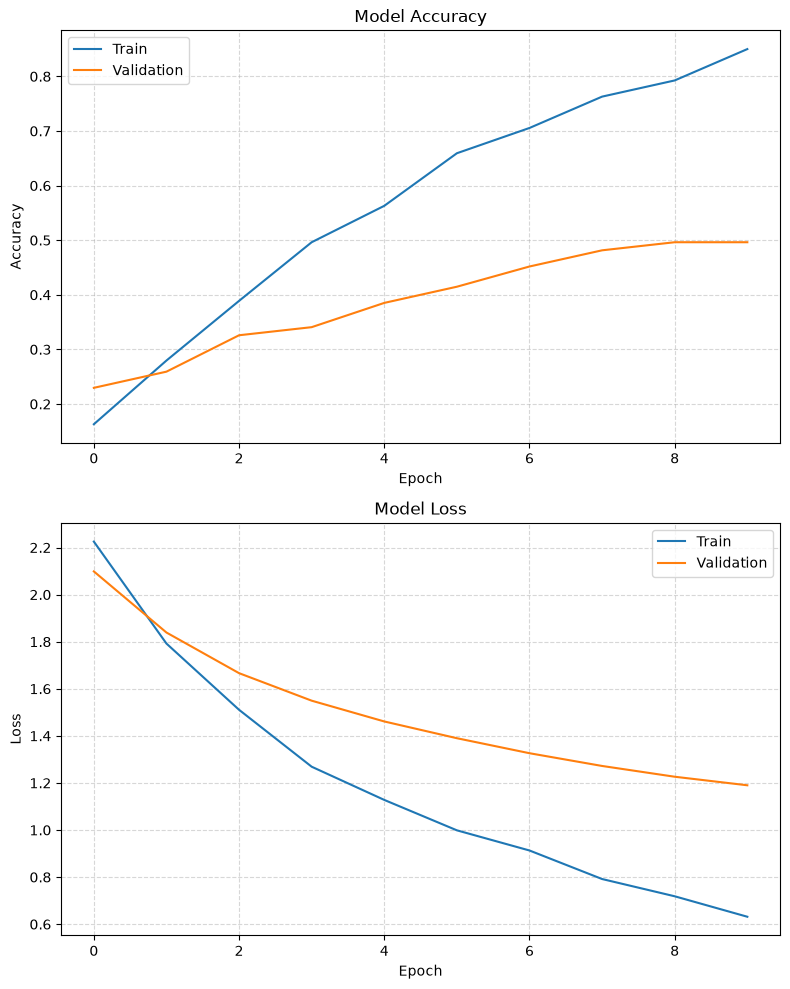

In [3]:
import matplotlib.pyplot as plt

# 1. Train the model using the optimized tf.data.Dataset pipelines
print("Starting Fine-Tuning training loop...")
epochs = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

# 2. Final evaluation on the Validation Dataset (unseen data)
print("\nEvaluating model on validation set...")
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

# 3. Plot training history (replicating Lab 5 visualization style)
plt.style.use("default") # Standard professional style
fig, ax = plt.subplots(2, 1, figsize=(8, 10))

# Plot Accuracy
ax[0].plot(history.history['accuracy'], label='Train')
ax[0].plot(history.history['val_accuracy'], label='Validation')
ax[0].set_title('Model Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.5)

# Plot Loss
ax[1].plot(history.history['loss'], label='Train')
ax[1].plot(history.history['val_loss'], label='Validation')
ax[1].set_title('Model Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

model.save("fine_tuned_resnet50_renal_pathology.h5")

Extracting a batch of validation images for TTA analysis...
Running Test-Time Augmentation (10 draws per image)...

Processing complete. Plotting comparison...


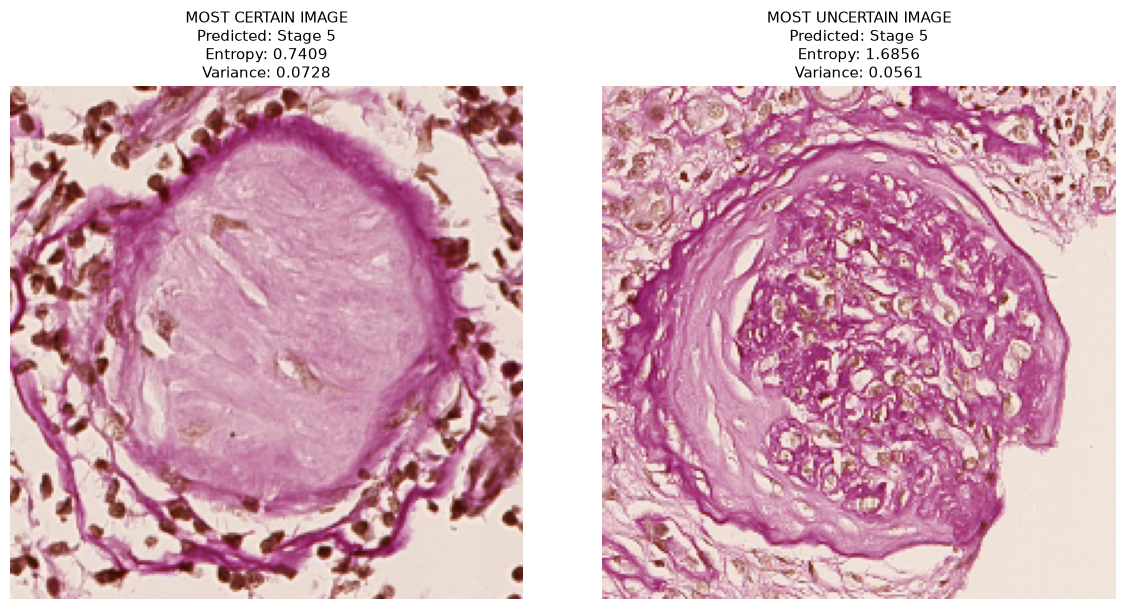

In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Clinically safe Data Augmentation for Digital Pathology (Rotational Invariance only)
# We only use Flips and Rotations because they preserve tissue scale (microns-per-pixel) 
# and biochemical stain colors (H&E), simulating a pathologist rotating the physical slide.
tta_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.5, fill_mode="constant", fill_value=255.0) # 0.5 allows up to 180 degrees rotation
])

def predict_with_tta(model, img_batch, num_draws=10):
    """
    Computes predictions multiple times on augmented versions of the input batch.
    Returns a numpy array of shape (num_draws, batch_size, num_classes).
    """
    tta_predictions = []
    
    # Run the first prediction on the original, unmodified image (deterministic)
    raw_pred = model.predict(img_batch, verbose=0)
    tta_predictions.append(raw_pred)
    
    # Run the subsequent predictions on augmented versions of the image
    for _ in range(num_draws - 1):
        # Force training=True to keep augmentation active during inference
        augmented_batch = tta_augmentation(img_batch, training=True)
        pred = model.predict(augmented_batch, verbose=0)
        tta_predictions.append(pred)
        
    return np.array(tta_predictions)

def compute_uncertainty_metrics(tta_preds):
    """
    Computes Predictive Entropy and Variance across all TTA draws.
    Matches the formulas implemented in Lab 6.
    """
    # Average the prediction probability vectors across all draws
    avg_preds = np.mean(tta_preds, axis=0)
    
    # 1. Predictive Entropy (Information theory uncertainty measure)
    eps = 1e-5
    entropy = -1 * np.sum(avg_preds * np.log(avg_preds + eps), axis=1)
    
    # 2. Predictive Variance (Disagreement measure among augmented predictions)
    variance = np.mean((tta_preds - avg_preds) ** 2, axis=0).sum(axis=1)
    
    return entropy, variance

# --- EXECUTION ON VALIDATION DATA ---
print("Extracting a batch of validation images for TTA analysis...")
for img_batch, label_batch in val_ds.take(1):
    
    # Run TTA (10 draws per image)
    print("Running Test-Time Augmentation (10 draws per image)...")
    tta_preds = predict_with_tta(model, img_batch, num_draws=10)
    
    # Calculate uncertainty metrics
    entropy, variance = compute_uncertainty_metrics(tta_preds)
    
    # Find the indices of the most certain and most uncertain predictions
    most_certain_idx = np.argmin(entropy)
    most_uncertain_idx = np.argmax(entropy)
    
    print("\nProcessing complete. Plotting comparison...")
    
    # Plotting comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Helper to denormalize ImageNet preprocessed images back to [0, 1] for visualization
    def denormalize(img):
        img_min = img.min()
        img_max = img.max()
        return (img - img_min) / (img_max - img_min)

    # Plot most certain image
    img_certain = denormalize(img_batch[most_certain_idx].numpy())
    predicted_stage_certain = np.argmax(np.mean(tta_preds[:, most_certain_idx, :], axis=0))
    axes[0].imshow(img_certain)
    axes[0].set_title(f"MOST CERTAIN IMAGE\nPredicted: Stage {predicted_stage_certain}\nEntropy: {entropy[most_certain_idx]:.4f}\nVariance: {variance[most_certain_idx]:.4f}", fontsize=11)
    axes[0].axis('off')
    
    # Plot most uncertain image
    img_uncertain = denormalize(img_batch[most_uncertain_idx].numpy())
    predicted_stage_uncertain = np.argmax(np.mean(tta_preds[:, most_uncertain_idx, :], axis=0))
    axes[1].imshow(img_uncertain)
    axes[1].set_title(f"MOST UNCERTAIN IMAGE\nPredicted: Stage {predicted_stage_uncertain}\nEntropy: {entropy[most_uncertain_idx]:.4f}\nVariance: {variance[most_uncertain_idx]:.4f}", fontsize=11)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [6]:
import os

# Define the directory and filename for the saved model
# We use the modern Keras '.keras' format, which is the standard in TensorFlow 2.x
model_dir = "./dataset_glomeruli_all"
model_file_name = "glomeruli_classifier.keras"
full_save_path = os.path.join(model_dir, model_file_name)

print("Saving the trained model to disk...")
model.save(full_save_path)

print(f"Success! Model saved and ready for deployment at: {full_save_path}")

Saving the trained model to disk...
Success! Model saved and ready for deployment at: ./dataset_glomeruli_all/glomeruli_classifier.keras
